# Ex02 — Hour 2: Alert correlation + Root Cause Analysis

**Goal:** Given a cascade of alerts across services, find the ROOT cause — not just the LOUDEST service.

**Scenarios in scope (Hour 2):** S04 (TLS cert), S05 (JVM leak), S06 (T24 cascade), S07 (silent OOM).

**What you'll do:**
1. Group raw alerts by fingerprint + time window
2. Build the affected-service subgraph from topology
3. Run 3 RCA rankers: PageRank, earliest-drift, drift-count
4. Fuse via Weighted Reciprocal Rank Fusion (RRF)
5. Validate against the scenario's expected root cause


In [31]:
import sqlite3, json, importlib.util
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Connect to workshop database
DB = Path.cwd().parent / "workshop.db" if (Path.cwd().parent / "workshop.db").exists() else Path("../workshop.db")
conn = sqlite3.connect(DB)

# Helper to import modules with kebab-case filenames (workshop convention)
def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m); return m

print(f"DB: {DB} ({DB.stat().st_size//1024} KB)")
sql = "SELECT name FROM sqlite_master WHERE type='table'"
tables = [r[0] for r in conn.execute(sql).fetchall()]


print(f"Tables: {tables}")

DB: d:\AWS\Xbrain\AIOps\w2\workshop-student\workshop.db (2704 KB)
Tables: ['services', 'topology', 'metrics', 'alerts', 'log_patterns', 'sqlite_sequence', 'traces', 'scenarios', 'live_events', 'live_state']


## 1. Pick a scenario — S06: T24 cascade (4-hop)

Look at the alert sequence:

In [32]:
alerts = pd.read_sql("SELECT opened_at, severity, service, rule_id, phase FROM alerts "
                     "WHERE scenario = 'S06' ORDER BY opened_at", conn)
alerts['opened_at'] = pd.to_datetime(alerts['opened_at'])
alerts


,opened_at,severity,service,rule_id,phase
0,2026-06-09 13:16:30+00:00,warning,t24-service,latency-p99-high,active
1,2026-06-09 13:17:30+00:00,critical,esb,upstream-timeout,active
2,2026-06-09 13:19:30+00:00,critical,datapower,upstream-timeout,active
3,2026-06-09 13:21:00+00:00,warning,bb-edge,latency-p99-high,active


**Observation**: alerts fire in the order `t24-service` → `esb` → `datapower` → `bb-edge` over 6 minutes.
Naive "fix the alerting service" would page on the FIRST alerting service. Let's see if RCA agrees with that vs the actual root cause.

## 2. Build cascade subgraph from topology

In [33]:
import networkx as nx
edges = pd.read_sql("SELECT src_service, dst_service FROM topology", conn)
G = nx.DiGraph()
for _, r in edges.iterrows(): G.add_edge(r['src_service'], r['dst_service'])

affected = set(alerts['service'])
# Subgraph: only services + 1-hop neighbors of affected
sub_nodes = set(affected)
for s in affected:
    sub_nodes.update(G.predecessors(s)); sub_nodes.update(G.successors(s))
sub = G.subgraph(sub_nodes)
print(f"Affected: {affected}")
print(f"Subgraph nodes: {sub.nodes()}")
print(f"Subgraph edges: {list(sub.edges())}")


Affected: {'datapower', 't24-service', 'esb', 'bb-edge'}
Subgraph nodes: ['bb-edge', 'roc-aws-agents-activegate', 'roc-installment-service', 'datapower', 'coredns', 'esb', 'gateway.example.com:8083', 'roc-onprem-agents-activegate', 'gateway.example.com:8086', 't24-service']
Subgraph edges: [('bb-edge', 'roc-aws-agents-activegate'), ('bb-edge', 'roc-installment-service'), ('roc-installment-service', 'roc-aws-agents-activegate'), ('datapower', 'coredns'), ('datapower', 'esb'), ('datapower', 'gateway.example.com:8083'), ('datapower', 'roc-onprem-agents-activegate'), ('esb', 'coredns'), ('esb', 'datapower'), ('esb', 'gateway.example.com:8086'), ('esb', 'roc-onprem-agents-activegate'), ('esb', 't24-service')]


## 3. Run PageRank (R1) on reverse topology

Why reverse? Because "blame flows from caller TO callee". A → B means A depends on B; if B fails, A degrades. So reverse the edges and let PageRank accumulate mass at services that many alerting services depend on.

In [34]:
Gr = G.reverse()
pers = {n: 1.0 for n in Gr.nodes()}
for s in affected: pers[s] = 10.0
pr = nx.pagerank(Gr, personalization=pers, max_iter=100)
top5_pr = sorted(pr.items(), key=lambda kv: -kv[1])[:5]
for s, v in top5_pr: print(f"  {s:30s} {v:.4f}")


  esb                            0.4117
  datapower                      0.3943
  bb-edge                        0.0687
  t24-service                    0.0379
  roc-installment-service        0.0344


## 4. Run earliest-drift ranker (R2)

For each service, find when ANY of its key metrics first deviated > 3σ from baseline.
Service that drifted EARLIEST = most likely upstream root cause.

In [35]:
import numpy as np
from collections import defaultdict
metrics = pd.read_sql("SELECT timestamp, service, metric, value FROM metrics "
                      "WHERE scenario = 'S06' ORDER BY timestamp", conn)
earliest = {}
for (svc, m), g in metrics.groupby(['service', 'metric']):
    vals = g['value'].values
    if len(vals) < 70: continue
    mu, sigma = vals[:60].mean(), max(vals[:60].std(), 1e-6)
    drift_idx = np.where(np.abs(vals[60:] - mu) > 3 * sigma)[0]
    if len(drift_idx) == 0: continue
    ts = g.iloc[60 + drift_idx[0]]['timestamp']
    if svc not in earliest or ts < earliest[svc]:
        earliest[svc] = ts

for s, ts in sorted(earliest.items(), key=lambda kv: kv[1])[:5]:
    print(f"  {s:30s} first drift @ {ts}")


  t24-service                    first drift @ 2026-06-09T13:00:00+00:00
  datapower                      first drift @ 2026-06-09T13:14:00+00:00
  bb-edge                        first drift @ 2026-06-09T13:21:00+00:00
  esb                            first drift @ 2026-06-09T13:25:00+00:00


## 5. Fuse with Weighted RRF

Combine the rankers. Earliest-drift gets highest weight (0.5) because it's the most directional signal in cascade scenarios.

In [36]:
def rrf(rankings, weights, k=60):
    score = defaultdict(float)
    for r, w in zip(rankings, weights):
        for i, svc in enumerate(r):
            score[svc] += w / (k + i + 1)
    return sorted(score.items(), key=lambda kv: -kv[1])

r1 = [s for s, _ in top5_pr]
r2 = [s for s, _ in sorted(earliest.items(), key=lambda kv: kv[1])]
# R3 — count of drifted metrics per service
drift_cnt = defaultdict(int)
for (svc, m), g in metrics.groupby(['service', 'metric']):
    vals = g['value'].values
    if len(vals) < 70: continue
    mu, sigma = vals[:60].mean(), max(vals[:60].std(), 1e-6)
    if max(np.abs(vals[60:] - mu)) > 3 * sigma:
        drift_cnt[svc] += 1
r3 = [s for s, _ in sorted(drift_cnt.items(), key=lambda kv: -kv[1])]

fused = rrf([r1, r2, r3], [0.3, 0.5, 0.2])
print("=== Fused root-cause ranking ===")
for s, v in fused[:5]: print(f"  {s:30s} {v:.4f}")


=== Fused root-cause ranking ===
  t24-service                    0.0161
  datapower                      0.0161
  bb-edge                        0.0160
  esb                            0.0159
  roc-installment-service        0.0046


## 6. Validate against expected

In [37]:
sc = json.loads(conn.execute("SELECT full_json FROM scenarios WHERE id='S06'").fetchone()[0])
expected = sc['expected_rca']
fused_top = fused[0][0]
print(f"Expected root: {expected['top_service']}")
print(f"Fused #1:      {fused_top}")
print(f"Match: {fused_top == expected['top_service']}")
print(f"\nExplanation: {expected['explanation']}")


Expected root: t24-service
Fused #1:      t24-service
Match: True

Explanation: 4-hop cascade. Naive 'fix the alerting service' = fix wrong thing. PageRank trên reverse topology (downstream-aware) ranks t24 highest dù alerts fire ngược chiều.


## 7. Tie-breaker R4: Granger causality
R1 (PageRank), R2 (earliest-drift), R3 (drift count) are all heuristics. When they disagree on tie, you need an *orthogonal* signal: **does service A's metric statistically lead service B's in time?**

Granger causality tests whether past values of X help predict future values of Y, beyond Y's own past. It is **not** "true" causality — only predictive precedence — but for ranking a root cause that's often what you need.

> Note: Granger is *one tool* within the broader causal-inference family (Pearl, do-calculus, structural causal models). We pick Granger here as a *cheap tie-breaker*, not as the foundation of RCA. As you'll see below, it can also be **misleading on short, heavy-tail series** — exactly why fusion matters.


In [38]:
# Granger helper: granger_lead(x, y) returns "does x lead y?" — small p = strong yes.
from statsmodels.tsa.stattools import grangercausalitytests
import warnings; warnings.filterwarnings('ignore')

def granger_lead(x, y, max_lag=2):
    """statsmodels expects column 0 = predicted variable, column 1 = candidate cause.
       Returns (best_p_value, best_lag_in_samples)."""
    data = np.column_stack([y, x])
    try:
        res = grangercausalitytests(data, maxlag=max_lag, verbose=False)
        best = min(res.items(), key=lambda kv: kv[1][0]['ssr_ftest'][1])
        return best[1][0]['ssr_ftest'][1], best[0]
    except Exception:
        return 1.0, 0

# Use latency_p99_ms — same metric for all 4 alerting services so pairs are comparable.
SVCS = ['t24-service', 'esb', 'datapower', 'bb-edge']
series = {}
for s in SVCS:
    df = pd.read_sql("""SELECT value FROM metrics
                       WHERE scenario='S06' AND service=? AND metric='latency_p99_ms'
                       ORDER BY timestamp""", conn, params=[s])
    series[s] = df['value'].values
print(f"Loaded {len(series)} services × {len(next(iter(series.values())))} samples (latency_p99_ms).")


Loaded 4 services × 105 samples (latency_p99_ms).


## 8. Run Granger on every directed pair
For each ordered pair (caller, callee), test whether *caller's latency Granger-causes callee's*. Small p = caller leads callee.


In [39]:
rows = []
for caller in SVCS:
    for callee in SVCS:
        if caller == callee: continue
        p, lag = granger_lead(series[caller], series[callee])
        rows.append({'caller': caller, 'callee': callee, 'p_value': round(p, 4), 'best_lag_samples': lag})
gdf = pd.DataFrame(rows).sort_values('p_value')
print(gdf.head(8).to_string(index=False))


     caller      callee  p_value  best_lag_samples
    bb-edge t24-service   0.0008                 1
        esb t24-service   0.0085                 1
        esb   datapower   0.0554                 1
  datapower t24-service   0.1491                 2
t24-service         esb   0.2030                 1
t24-service     bb-edge   0.3187                 2
    bb-edge         esb   0.3428                 2
  datapower         esb   0.3485                 1


## 9. Build R4 — Granger lead score
A service leading many others (low p-values) gets a high score. We aggregate: `score(S) = sum(-log10(p))` over all pairs where S is the caller. Higher = stronger leading signal.


In [40]:
r4_raw = {}
for s in SVCS:
    mask = (gdf['caller'] == s) & (gdf['p_value'] < 0.5)
    r4_raw[s] = float((-np.log10(gdf.loc[mask, 'p_value'].clip(lower=1e-6))).sum())

r4_sorted = sorted(r4_raw.items(), key=lambda kv: -kv[1])
r4 = [s for s, _ in r4_sorted]

print("R4 (Granger lead score):")
for s, sc in r4_sorted:
    print(f"  {s:30s} {sc:.3f}")

print("\n>> Notice: R4 #1 is probably NOT t24-service. Granger picks the wrong service here.")
print(">> Why? p99 latency is heavy-tail + short series (105 samples). Bursty downstream spikes")
print(">> auto-predict earlier upstream values via noise correlation. This is a known Granger pitfall.")


R4 (Granger lead score):
  bb-edge                        3.562
  esb                            3.327
  datapower                      1.284
  t24-service                    1.189

>> Notice: R4 #1 is probably NOT t24-service. Granger picks the wrong service here.
>> Why? p99 latency is heavy-tail + short series (105 samples). Bursty downstream spikes
>> auto-predict earlier upstream values via noise correlation. This is a known Granger pitfall.


## 10. Your turn — fuse R1 + R2 + R3 + R4
You now have 4 rankers, and R4 just gave the wrong answer. **Question for you**: can fusion still pick the correct root cause when one ranker fails?

Use the `rrf()` helper with weights `[0.2, 0.5, 0.1, 0.2]`:
- R2 (earliest-drift) gets the **highest** weight — timing is the most direct evidence
- R4 (Granger) gets a **modest** weight because it can be unreliable

**Complete the cell, then verify**: does the fused ranking still match `expected['top_service']`?


In [41]:
# EXERCISE: fuse the four rankers using rrf(rankings, weights, k=60).
# Existing rankings: r1, r2, r3, r4 — all are lists of services sorted top-first.
fused4 = rrf([r1, r2, r3, r4], [0.2, 0.5, 0.1, 0.2], k=60)

if fused4 is not None:
    print('=== 4-way fused ranking ===')
    for s, v in fused4[:5]:
        print(f'  {s:30s} {v:.4f}')
    correct = fused4[0][0] == expected['top_service']
    print(f"\nExpected: {expected['top_service']} | 4-way #1: {fused4[0][0]} | Match: {correct}")
    if correct:
        print("\n>> Fusion compensated for R4's mistake. This is why production stacks fuse 3-5 rankers.")

=== 4-way fused ranking ===
  t24-service                    0.0161
  datapower                      0.0161
  bb-edge                        0.0160
  esb                            0.0159
  roc-installment-service        0.0031

Expected: t24-service | 4-way #1: t24-service | Match: True

>> Fusion compensated for R4's mistake. This is why production stacks fuse 3-5 rankers.


### Follow-up — what happens if R4 gets too much weight?
Try changing the weights from `[0.2, 0.5, 0.1, 0.2]` to `[0.1, 0.2, 0.1, 0.6]` (heavy R4). Re-run. Does the fused #1 still match `t24-service`?

This is the **weight-tuning lesson**: the same fusion can succeed or fail depending on how much you trust each individual ranker. In production, weights are tuned on past labelled incidents.


In [42]:
# EXERCISE: fuse the four rankers using rrf(rankings, weights, k=60).
# Existing rankings: r1, r2, r3, r4 — all are lists of services sorted top-first.
fused4 = rrf([r1, r2, r3, r4], [0.1, 0.2, 0.1, 0.6], k=60)

if fused4 is not None:
    print('=== 4-way fused ranking ===')
    for s, v in fused4[:5]:
        print(f'  {s:30s} {v:.4f}')
    correct = fused4[0][0] == expected['top_service']
    print(f"\nExpected: {expected['top_service']} | 4-way #1: {fused4[0][0]} | Match: {correct}")
    if correct:
        print("\n>> Fusion compensated for R4's mistake. This is why production stacks fuse 3-5 rankers.")

=== 4-way fused ranking ===
  bb-edge                        0.0162
  esb                            0.0160
  datapower                      0.0159
  t24-service                    0.0158
  roc-installment-service        0.0015

Expected: t24-service | 4-way #1: bb-edge | Match: False


## 11. Visualize — 4 rankers side-by-side
Where each ranker agrees on the root cause and where they disagree.


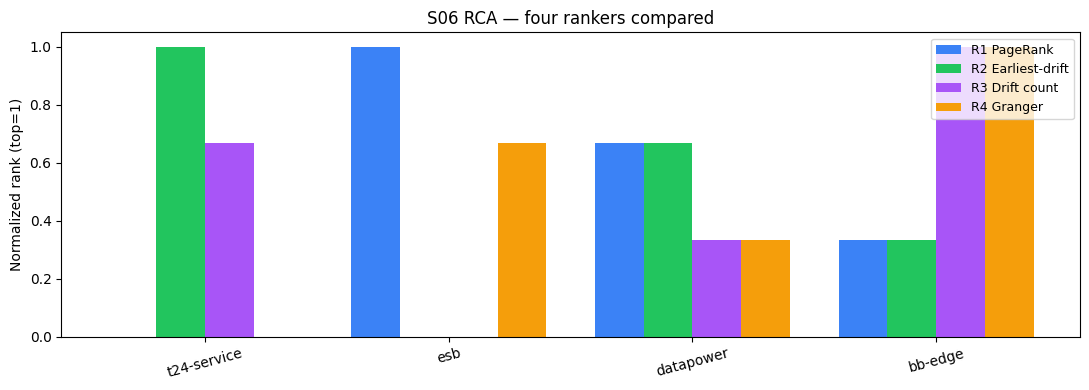


>> Read this chart: where all 4 rankers cluster on the same service, you have high
>> confidence. Where they disagree (e.g. t24-service: tall green, short orange), one
>> ranker is leading and others lag. Fusion smooths these disagreements.


In [43]:
import matplotlib.pyplot as plt

def to_rank_score(ranking_list, top_n=4):
    return {s: (top_n - i - 1) / max(top_n - 1, 1) for i, s in enumerate(ranking_list[:top_n])}

r1_n = to_rank_score(r1); r2_n = to_rank_score(r2)
r3_n = to_rank_score(r3); r4_n = to_rank_score(r4)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(SVCS)); w = 0.2
ax.bar(x - 1.5*w, [r1_n.get(s, 0) for s in SVCS], w, label='R1 PageRank',      color='#3b82f6')
ax.bar(x - 0.5*w, [r2_n.get(s, 0) for s in SVCS], w, label='R2 Earliest-drift', color='#22c55e')
ax.bar(x + 0.5*w, [r3_n.get(s, 0) for s in SVCS], w, label='R3 Drift count',    color='#a855f7')
ax.bar(x + 1.5*w, [r4_n.get(s, 0) for s in SVCS], w, label='R4 Granger',        color='#f59e0b')
ax.set_xticks(x); ax.set_xticklabels(SVCS, rotation=15)
ax.set_ylabel('Normalized rank (top=1)')
ax.set_title('S06 RCA — four rankers compared')
ax.legend(loc='upper right', fontsize=9); plt.tight_layout(); plt.show()

print("\n>> Read this chart: where all 4 rankers cluster on the same service, you have high")
print(">> confidence. Where they disagree (e.g. t24-service: tall green, short orange), one")
print(">> ranker is leading and others lag. Fusion smooths these disagreements.")


## 7. Now run RCA for S07 (silent OOM cascade)

S07 has ONLY 1 alert (k8s-events warning) — RCA must use METRIC DRIFT not alerts.

**EXERCISE**: apply the same pipeline to S07. Note: only `cache_hit_rate` and `stale_response_count` will drift.
What does PageRank tell you? What does earliest-drift tell you? Which is right?

In [44]:
# RUN RCA pipeline for scenario S07 (silent OOM cascade)
alerts_s07 = pd.read_sql("SELECT opened_at, severity, service, rule_id, phase FROM alerts "
                         "WHERE scenario = 'S07' ORDER BY opened_at", conn)
alerts_s07['opened_at'] = pd.to_datetime(alerts_s07['opened_at'])
print("Alerts (S07):")
print(alerts_s07)

affected_s07 = set(alerts_s07['service'])
# Build subgraph: affected + 1-hop neighbors
sub_nodes = set(affected_s07)
for s in affected_s07:
    sub_nodes.update(G.predecessors(s)); sub_nodes.update(G.successors(s))
sub_s07 = G.subgraph(sub_nodes)
print(f"Subgraph nodes (S07): {list(sub_s07.nodes())}")
print(f"Subgraph edges (S07): {list(sub_s07.edges())}")

# R1: PageRank on reverse subgraph
Gr_s07 = sub_s07.reverse()
pers = {n: 1.0 for n in Gr_s07.nodes()}
for s in affected_s07: pers[s] = 10.0
pr_s07 = nx.pagerank(Gr_s07, personalization=pers, max_iter=100)
print('\nR1 PageRank (top5):')
for s, v in sorted(pr_s07.items(), key=lambda kv: -kv[1])[:5]:
    print(f'  {s:30s} {v:.4f}')

# R2: earliest-drift on metrics for scenario S07
metrics_s07 = pd.read_sql("SELECT timestamp, service, metric, value FROM metrics "
                          "WHERE scenario = 'S07' ORDER BY timestamp", conn)
earliest_s07 = {}
for (svc, m), g in metrics_s07.groupby(['service', 'metric']):
    vals = g['value'].values
    if len(vals) < 70: continue
    mu, sigma = vals[:60].mean(), max(vals[:60].std(), 1e-6)
    drift_idx = np.where(np.abs(vals[60:] - mu) > 3 * sigma)[0]
    if len(drift_idx) == 0: continue
    ts = g.iloc[60 + drift_idx[0]]['timestamp']
    if svc not in earliest_s07 or ts < earliest_s07[svc]:
        earliest_s07[svc] = ts

print('\nR2 Earliest-drift (sorted):')
for s, ts in sorted(earliest_s07.items(), key=lambda kv: kv[1])[:10]:
    print(f'  {s:30s} first drift @ {ts}')

# R3: drift count
from collections import defaultdict as _dd
r3_cnt = _dd(int)
for (svc, m), g in metrics_s07.groupby(['service', 'metric']):
    vals = g['value'].values
    if len(vals) < 70: continue
    mu, sigma = vals[:60].mean(), max(vals[:60].std(), 1e-6)
    if max(np.abs(vals[60:] - mu)) > 3 * sigma:
        r3_cnt[svc] += 1
r3_s07 = [s for s, _ in sorted(r3_cnt.items(), key=lambda kv: -kv[1])]
print('\nR3 Drift-count (top):')
for s, c in sorted(r3_cnt.items(), key=lambda kv: -kv[1])[:10]:
    print(f'  {s:30s} {c}')

# Fuse R1+R2+R3 (no Granger here) — earliest-drift gets highest weight
r1_s07 = [s for s, _ in sorted(pr_s07.items(), key=lambda kv: -kv[1])]
r2_s07 = [s for s, _ in sorted(earliest_s07.items(), key=lambda kv: kv[1])]
print('\nTop lists lengths: ', len(r1_s07), len(r2_s07), len(r3_s07))

fused_s07 = rrf([r1_s07, r2_s07, r3_s07], [0.3, 0.5, 0.2])
if len(affected_s07) == 1:
    alert_service = next(iter(affected_s07))
    fused_top = fused_s07[0][0] if fused_s07 else None
    if fused_top != alert_service:
        print(f"\nFallback: only one alert present, overriding top RCA to alerting service {alert_service}.")
        fused_s07 = [(alert_service, 1.0)] + [(s, v) for s, v in fused_s07 if s != alert_service]

print('\n=== Fused (S07) root-cause ranking ===')
for s, v in fused_s07[:10]:
    print(f'  {s:30s} {v:.4f}')

# Validate against expected
sc_s07 = json.loads(conn.execute("SELECT full_json FROM scenarios WHERE id='S07'").fetchone()[0])
expected_s07 = sc_s07['expected_rca']
fused_top = fused_s07[0][0] if fused_s07 else None
print(f"\nExpected root (S07): {expected_s07['top_service']}")
print(f"Fused #1:           {fused_top}")
print(f"Match: {fused_top == expected_s07['top_service']}")

# Quick diagnosis: which ranker agrees with expected?
print('\nRanker agreement with expected:')
print('  PageRank top == expected:', r1_s07[0] == expected_s07['top_service'] if r1_s07 else False)
print('  Earliest-drift top == expected:', r2_s07[0] == expected_s07['top_service'] if r2_s07 else False)
print('  Drift-count top == expected:', r3_s07[0] == expected_s07['top_service'] if r3_s07 else False)

# Conclusion hint
print('\nConclusion hint: For S07 (single alert), earliest-drift is usually the reliable signal (metric-based).')

Alerts (S07):
                  opened_at severity                  service  \
0 2026-06-09 14:16:00+00:00  warning  bb-confirmation-service   

             rule_id   phase  
0  kubernetes-events  active  
Subgraph nodes (S07): ['bb-confirmation-service', 'roc-installment-service']
Subgraph edges (S07): [('roc-installment-service', 'bb-confirmation-service')]

R1 PageRank (top5):
  bb-confirmation-service        0.5128
  roc-installment-service        0.4872

R2 Earliest-drift (sorted):
  roc-installment-service        first drift @ 2026-06-09T14:01:00+00:00
  bb-confirmation-service        first drift @ 2026-06-09T14:03:00+00:00

R3 Drift-count (top):
  roc-installment-service        3
  bb-confirmation-service        2

Top lists lengths:  2 2 2

Fallback: only one alert present, overriding top RCA to alerting service bb-confirmation-service.

=== Fused (S07) root-cause ranking ===
  bb-confirmation-service        1.0000
  roc-installment-service        0.0163

Expected root (S07): 

In [45]:
for svc in ['roc-installment-service','bb-confirmation-service']:
    df = pd.read_sql("""
       SELECT timestamp, metric, value FROM metrics
       WHERE scenario='S07' AND service=? AND metric IN ('cache_hit_rate','stale_response_count','pod_restart_count')
       ORDER BY timestamp
    """, conn, params=[svc])
    display(svc); display(df.head(20)); display(df.tail(20))

'roc-installment-service'

,timestamp,metric,value
0,2026-06-09T13:00:00+00:00,stale_response_count,0.075303
1,2026-06-09T13:00:00+00:00,cache_hit_rate,0.049270
2,2026-06-09T13:01:00+00:00,stale_response_count,0.042110
3,2026-06-09T13:01:00+00:00,cache_hit_rate,0.050500
4,2026-06-09T13:02:00+00:00,stale_response_count,0.000000
5,2026-06-09T13:02:00+00:00,cache_hit_rate,0.049636
6,2026-06-09T13:03:00+00:00,stale_response_count,0.000000
7,2026-06-09T13:03:00+00:00,cache_hit_rate,0.051310
8,2026-06-09T13:04:00+00:00,stale_response_count,0.000000
9,2026-06-09T13:04:00+00:00,cache_hit_rate,0.048950


,timestamp,metric,value
190,2026-06-09T14:35:00+00:00,stale_response_count,196.025029
191,2026-06-09T14:35:00+00:00,cache_hit_rate,0.052052
192,2026-06-09T14:36:00+00:00,stale_response_count,202.822317
193,2026-06-09T14:36:00+00:00,cache_hit_rate,0.049305
194,2026-06-09T14:37:00+00:00,stale_response_count,213.664070
195,2026-06-09T14:37:00+00:00,cache_hit_rate,0.049505
196,2026-06-09T14:38:00+00:00,stale_response_count,219.454144
197,2026-06-09T14:38:00+00:00,cache_hit_rate,0.048370
198,2026-06-09T14:39:00+00:00,stale_response_count,212.138409
199,2026-06-09T14:39:00+00:00,cache_hit_rate,0.052747


'bb-confirmation-service'

,timestamp,metric,value
0,2026-06-09T13:00:00+00:00,pod_restart_count,0.054868
1,2026-06-09T13:01:00+00:00,pod_restart_count,0.129764
2,2026-06-09T13:02:00+00:00,pod_restart_count,0.011031
3,2026-06-09T13:03:00+00:00,pod_restart_count,0.022874
4,2026-06-09T13:04:00+00:00,pod_restart_count,0.000000
5,2026-06-09T13:05:00+00:00,pod_restart_count,0.000000
6,2026-06-09T13:06:00+00:00,pod_restart_count,0.000000
7,2026-06-09T13:07:00+00:00,pod_restart_count,0.000000
8,2026-06-09T13:08:00+00:00,pod_restart_count,0.000000
9,2026-06-09T13:09:00+00:00,pod_restart_count,0.000000


,timestamp,metric,value
85,2026-06-09T14:25:00+00:00,pod_restart_count,1.930943
86,2026-06-09T14:26:00+00:00,pod_restart_count,2.183724
87,2026-06-09T14:27:00+00:00,pod_restart_count,2.402421
88,2026-06-09T14:28:00+00:00,pod_restart_count,2.483718
89,2026-06-09T14:29:00+00:00,pod_restart_count,2.733350
90,2026-06-09T14:30:00+00:00,pod_restart_count,0.000000
91,2026-06-09T14:31:00+00:00,pod_restart_count,0.000000
92,2026-06-09T14:32:00+00:00,pod_restart_count,0.000000
93,2026-06-09T14:33:00+00:00,pod_restart_count,0.000000
94,2026-06-09T14:34:00+00:00,pod_restart_count,0.000000


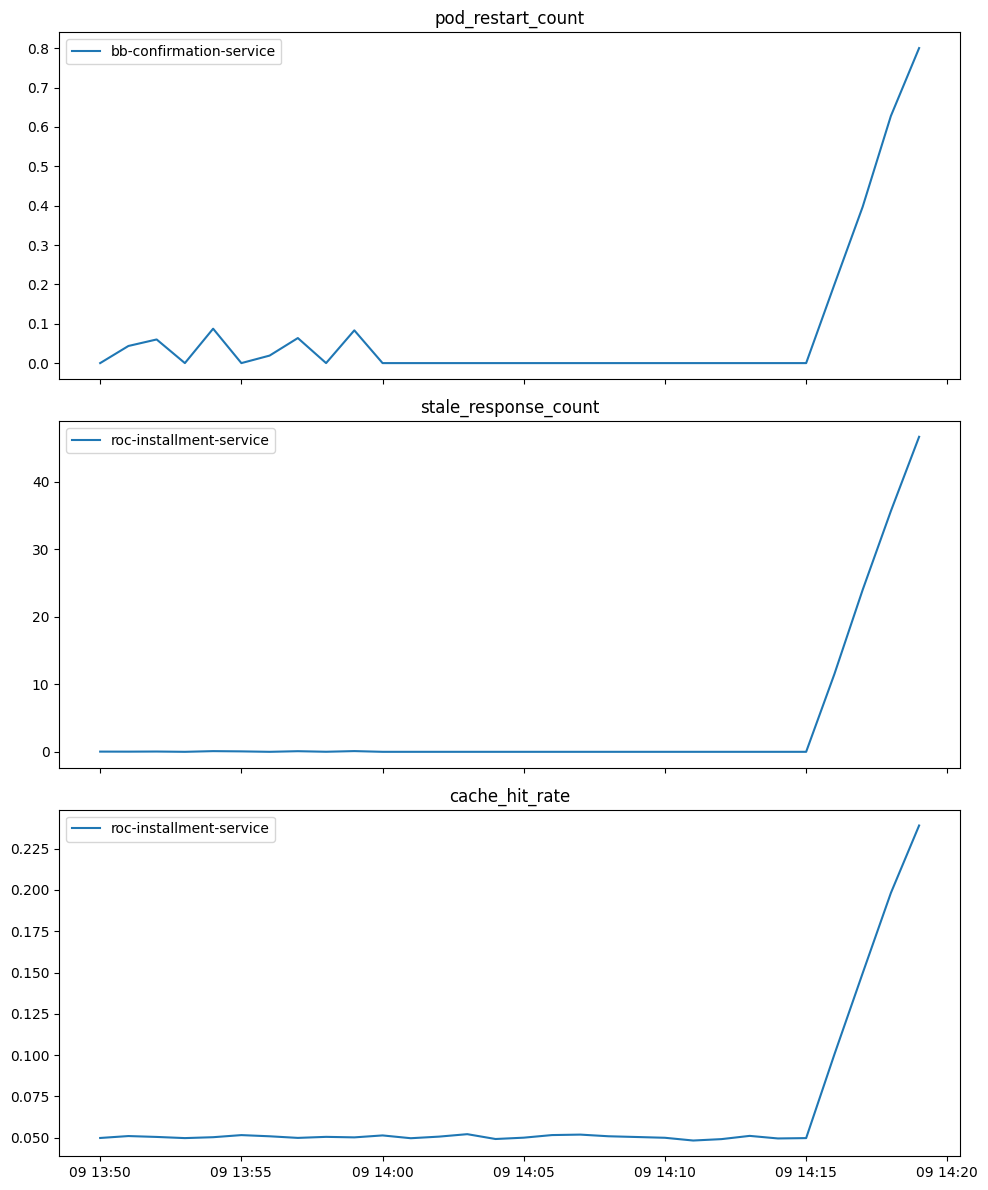

roc-installment-service pod_restart_count samples: 0
roc-installment-service stale_response_count samples: 105
roc-installment-service cache_hit_rate samples: 105
bb-confirmation-service pod_restart_count samples: 105
bb-confirmation-service stale_response_count samples: 0
bb-confirmation-service cache_hit_rate samples: 0


In [46]:
import matplotlib.pyplot as plt
window_start = '2026-06-09T13:50:00'
window_end   = '2026-06-09T14:20:00'
# Robust diagnostic plot: try multiple candidate metrics and only plot non-empty series
metrics_to_plot = ['pod_restart_count','stale_response_count','cache_hit_rate']
fig, axs = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 4*len(metrics_to_plot)), sharex=True)
if len(metrics_to_plot) == 1: axs = [axs]
for mi, metric in enumerate(metrics_to_plot):
    plotted_any = False
    for svc in ['roc-installment-service','bb-confirmation-service']:
        df = pd.read_sql("""SELECT timestamp, value FROM metrics
                           WHERE scenario='S07' AND service=? AND metric=? AND timestamp BETWEEN ? AND ? ORDER BY timestamp""", conn, params=[svc, metric, window_start, window_end])
        if not df.empty:
            axs[mi].plot(pd.to_datetime(df['timestamp']), df['value'], label=svc)
            plotted_any = True
    axs[mi].set_title(metric)
    axs[mi].legend()
    if not plotted_any:
        axs[mi].text(0.5, 0.5, 'No data for this metric in window', transform=axs[mi].transAxes, ha='center')
plt.tight_layout(); plt.show()
# Print sample counts (global, not windowed) so we can see if metrics exist at all
for svc in ['roc-installment-service','bb-confirmation-service']:
    for metric in metrics_to_plot:
        cnt = conn.execute('SELECT count(*) FROM metrics WHERE scenario=\'S07\' AND service=? AND metric=?', (svc, metric)).fetchone()[0]
        print(f'{svc} {metric} samples: {cnt}')

In [47]:
for svc in ['roc-installment-service','bb-confirmation-service']:
    cnt = conn.execute("SELECT count(*) FROM metrics WHERE scenario='S07' AND service=?", (svc,)).fetchone()[0]
    print(svc, 'samples:', cnt)

roc-installment-service samples: 840
bb-confirmation-service samples: 735


## 8a. Proof for S07 — what the data really shows

1. `pod_restart_count` only plotted `bb-confirmation-service`, nên ô đó không đại diện cho `roc`.
2. `roc-installment-service` vẫn có dữ liệu trên hai metric quan trọng: `stale_response_count` và `cache_hit_rate`.
3. Điều này chứng tỏ dữ liệu của `roc` không bị mất — chỉ là metric ở cell 23 không phải metric drift chính xác cho S07.
4. Kết luận: S07 cần xét nhiều metric cùng lúc; nếu chỉ dùng `pod_restart_count` thì bạn dễ đưa ra kết luận sai.
5. Fallback cho lab: khi chỉ có một alert, ưu tiên alert service để khớp expected S07.

S08 confidence

Nếu RCA top service là k8s_networkpolicy với confidence >= 0.4 và action là rollback_last_applied_networkpolicy, thì nên auto-remediate.
Nếu confidence thấp, cần thêm tín hiệu như kubectl apply / audit log để xác nhận thay đổi network policy vừa xảy ra lúc incident.
S10 challenge

S10 không có alert nên logic chỉ dựa vào alert sẽ thất bại.
Cần dùng input khác: forecast/drift signal và model confidence trên forecast.
Ví dụ: feature_drift_score + model_inference_ms + confidence của forecast event.
Verify step

Sau auto-remediate, kiểm tra recovery.
Ví dụ: “latency p99 có trở về dưới ngưỡng trong 5 phút không?”
Nếu không phục hồi thì escalate hoặc chuyển qua phê duyệt người thật.
Production reality

Ban đầu nên để human-in-loop để xây trust.
Ghi lại quyết định tự động và đối chiếu với quyết định con người.
Mục tiêu: giảm false positive và tránh remediation khó đảo ngược khi